Importando as bibliotecas e módulos necessários: 

In [1]:
import os
import pandas as pd
import numpy as np
import sys
import gc
import scipy.stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

Importando as bases necessárias: 

In [2]:
df_2019 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2019.parquet", engine="pyarrow")
df_2021 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2021.parquet", engine="pyarrow")
df_2023 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2023.parquet", engine="pyarrow")

### Modelagem Preditiva 
Esse código implementa modelos de Regressão Logística para prever se um aluno será Insuficiente ou Proficiente.

#### Regressão Logística com Balanceamento dos Dados de treino utilizando 'RandomUnderSampler' 
O balanceamento dos dados ocorre quando há uma classe dominante, como, por exemplo, muitos "Insuficientes" e poucos "Proficientes" e o modelo aprende a prever apenas a classe majoritária. O que o undersampling faz é reduzir artificialmente a classe maior.

#### 2019

Distribuição das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    1240187
1     289357
Name: count, dtype: int64

Porcentagem das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    81.08214
1    18.91786
Name: proportion, dtype: float64

Distribuição das classes após o balanceamento com Undersampling:
PROFICIENCIA_DESCRICAO
0    289357
1    289357
Name: count, dtype: int64

Porcentagem das classes após o balanceamento com Undersampling:
PROFICIENCIA_DESCRICAO
0    50.0
1    50.0
Name: proportion, dtype: float64
Optimization terminated successfully.
         Current function value: 0.615343
         Iterations 6

Acurácia: 0.6310

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.90      0.61      0.73    309691
 Proficiente       0.30      0.71      0.42     72696

    accuracy                           0.63    382387
   macro avg       0.60      0.66      0.58    382387
weighted avg       0.79      0.63      0.67    

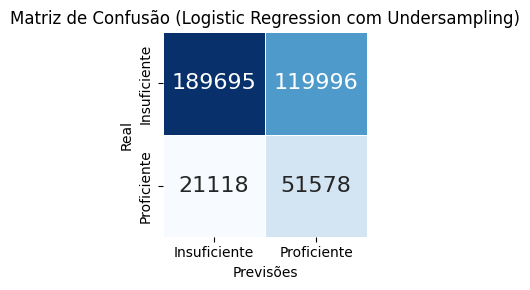


Coeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com Undersampling:
                                       Feature  Coefficient  Odds Ratio  \
0                                    Intercept     0.626815    1.871639   
16                    QTD_COMPUTADOR_3 ou mais     0.424414    1.528694   
25              IDADE_INTROD_ESC_Não respondeu     0.367793    1.444543   
15                       QTD_COMPUTADOR_1 ou 2     0.314241    1.369220   
11                 ESCOL_MAE_Superior completo     0.283269    1.327462   
38                      POS_EF_Somente estudar     0.274067    1.315303   
20                     QTD_CARRO_Não respondeu     0.226179    1.253800   
18                            QTD_CARRO_1 ou 2     0.206169    1.228961   
8                     ESCOL_MAE_Médio completo     0.159143    1.172506   
22                                 GARAGEM_Sim     0.151494    1.163571   
3                       COR_RACA_Não respondeu     0.133337    1.142635   
19        

In [4]:
# Como a regressão logística só trabalha com números, variáveis categóricas como 'Sexo' precisam virar colunas numéricas. O 'get_dummies()' faz isso. 
# O 'drop_first=True' remove uma categoria para evitar multicolinearidade, ou seja, se 'Masculino' = 1, então 'Feminino' = 0 automaticamente
X = pd.get_dummies(df_2019.drop(columns=['PROFICIENCIA_DESCRICAO']), drop_first=True)

# Redução do número de classes inicialmente adotado. Essa redução é necessária para a aplicação do modelo e contribui para um desempenho e estabilidade maiores
df_2019['PROFICIENCIA_DESCRICAO'] = (df_2019['PROFICIENCIA_DESCRICAO'].replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Como a regressão logística precisa prever números binários, então: 'Insuficiente' → 0 e 'Proficiente' → 1
y = df_2019['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Divisão dos dados em treino(ensinar o modelo) e teste(avaliar o modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Garantindo que os dados de entrada são do tipo float para evitar problemas matemáticos
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Exibindo a quantidade e porcentagem das classes antes do balanceamento
print("Distribuição das classes antes do balanceamento:")
print(y_train.value_counts())
print("\nPorcentagem das classes antes do balanceamento:")
print(y_train.value_counts(normalize=True) * 100)

# Aplicando RandomUnderSampler para balancear as classes no conjunto de treinamento
undersampler = RandomUnderSampler(random_state=42)
X_train_undersample, y_train_undersample = undersampler.fit_resample(X_train, y_train)

# Exibindo a quantidade e porcentagem das classes após o balanceamento
print("\nDistribuição das classes após o balanceamento com Undersampling:")
print(y_train_undersample.value_counts())
print("\nPorcentagem das classes após o balanceamento com Undersampling:")
print(y_train_undersample.value_counts(normalize=True) * 100)

# Adicionando a constante (intercepto) para o modelo 
X_train_undersample = sm.add_constant(X_train_undersample)
X_test = sm.add_constant(X_test)

# Ajustando o modelo de regressão logística 
log_reg_stats = sm.Logit(y_train_undersample, X_train_undersample).fit()

# Previsões no conjunto de teste
y_pred = (log_reg_stats.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logistic Regression com Undersampling)")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = log_reg_stats.params
features = ['Intercept'] + list(X.columns)  # Inclui o intercepto no nome das variáveis

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = log_reg_stats.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})

# Ordenando por Odds Ratio
coef_df['Abs_Odds_Ratio'] = coef_df['Odds Ratio'].abs()
coef_df = coef_df.sort_values('Abs_Odds_Ratio', ascending=False)
print("\nCoeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com Undersampling:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio', 'p-value']])


#### 2021

In [5]:
# Como a regressão logística só trabalha com números, variáveis categóricas como 'Sexo' precisam virar colunas numéricas. O 'get_dummies()' faz isso. 
# O 'drop_first=True' remove uma categoria para evitar multicolinearidade, ou seja, se 'Masculino' = 1, então 'Feminino' = 0 automaticamente
X = pd.get_dummies(df_2021.drop(columns=['PROFICIENCIA_DESCRICAO']), drop_first=True)

# Redução do número de classes inicialmente adotado. Essa redução é necessária para a aplicação do modelo e contribui para um desempenho e estabilidade maiores
df_2021['PROFICIENCIA_DESCRICAO'] = (
    df_2021['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Como a regressão logística precisa prever números binários, então: 'Insuficiente' → 0 e 'Proficiente' → 1
y = df_2021['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Divisão dos dados em treino(ensinar o modelo) e teste(avaliar o modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Garantindo que os dados de entrada são do tipo float para evitar problemas matemáticos
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Exibindo a quantidade e porcentagem das classes antes do balanceamento
print("Distribuição das classes antes do balanceamento:")
print(y_train.value_counts())
print("\nPorcentagem das classes antes do balanceamento:")
print(y_train.value_counts(normalize=True) * 100)

# Aplicando RandomUnderSampler para balancear as classes no conjunto de treinamento
undersampler = RandomUnderSampler(random_state=42)
X_train_undersample, y_train_undersample = undersampler.fit_resample(X_train, y_train)

# Exibindo a quantidade e porcentagem das classes após o balanceamento
print("\nDistribuição das classes após o balanceamento com Undersampling:")
print(y_train_undersample.value_counts())
print("\nPorcentagem das classes após o balanceamento com Undersampling:")
print(y_train_undersample.value_counts(normalize=True) * 100)

# Adicionando a constante (intercepto) para o modelo 
X_train_undersample = sm.add_constant(X_train_undersample)
X_test = sm.add_constant(X_test)

# Ajustando o modelo de regressão logística 
log_reg_stats = sm.Logit(y_train_undersample, X_train_undersample).fit()

# Previsões no conjunto de teste
y_pred = (log_reg_stats.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logistic Regression com Undersampling)")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = log_reg_stats.params
features = ['Intercept'] + list(X.columns)  # Inclui o intercepto no nome das variáveis

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = log_reg_stats.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})

# Ordenando por Odds Ratio
coef_df['Abs_Odds_Ratio'] = coef_df['Odds Ratio'].abs()
coef_df = coef_df.sort_values('Abs_Odds_Ratio', ascending=False)
print("\nCoeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com Undersampling:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio', 'p-value']])


Distribuição das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    1268427
1     240516
Name: count, dtype: int64

Porcentagem das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    84.060631
1    15.939369
Name: proportion, dtype: float64

Distribuição das classes após o balanceamento com Undersampling:
PROFICIENCIA_DESCRICAO
0    240516
1    240516
Name: count, dtype: int64

Porcentagem das classes após o balanceamento com Undersampling:
PROFICIENCIA_DESCRICAO
0    50.0
1    50.0
Name: proportion, dtype: float64
Optimization terminated successfully.
         Current function value: 0.598922
         Iterations 6


LinAlgError: Singular matrix

#### 2023

Distribuição das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    1365681
1     276443
Name: count, dtype: int64

Porcentagem das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    83.165522
1    16.834478
Name: proportion, dtype: float64

Distribuição das classes após o balanceamento com Undersampling:
PROFICIENCIA_DESCRICAO
0    276443
1    276443
Name: count, dtype: int64

Porcentagem das classes após o balanceamento com Undersampling:
PROFICIENCIA_DESCRICAO
0    50.0
1    50.0
Name: proportion, dtype: float64
Optimization terminated successfully.
         Current function value: 0.610566
         Iterations 6

Acurácia: 0.6429

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.91      0.63      0.75    341565
 Proficiente       0.28      0.70      0.40     68967

    accuracy                           0.64    410532
   macro avg       0.59      0.67      0.57    410532
weighted avg       0.81      0.64      0.69  

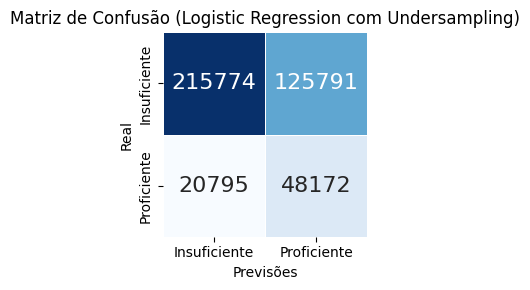


Coeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com Undersampling:
                                       Feature  Coefficient  Odds Ratio  \
4                           SEXO_Não respondeu     0.768198    2.155877   
2                               SEXO_Masculino     0.644863    1.905726   
19                    QTD_COMPUTADOR_3 ou mais     0.471319    1.602106   
14                 ESCOL_MAE_Superior completo     0.339963    1.404895   
18                       QTD_COMPUTADOR_1 ou 2     0.325694    1.384992   
3                       SEXO_Não quis declarar     0.306641    1.358852   
0                                    Intercept     0.290013    1.336445   
24                       GARAGEM_Não respondeu     0.269480    1.309283   
41                      POS_EF_Somente estudar     0.231627    1.260650   
11                    ESCOL_MAE_Médio completo     0.218371    1.244049   
21                            QTD_CARRO_1 ou 2     0.180170    1.197421   
28        

In [6]:
# Como a regressão logística só trabalha com números, variáveis categóricas como 'Sexo' precisam virar colunas numéricas. O 'get_dummies()' faz isso. 
# O 'drop_first=True' remove uma categoria para evitar multicolinearidade, ou seja, se 'Masculino' = 1, então 'Feminino' = 0 automaticamente
X = pd.get_dummies(df_2023.drop(columns=['PROFICIENCIA_DESCRICAO']), drop_first=True)

# Redução do número de classes inicialmente adotado. Essa redução é necessária para a aplicação do modelo e contribui para um desempenho e estabilidade maiores
df_2023['PROFICIENCIA_DESCRICAO'] = (
    df_2023['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Como a regressão logística precisa prever números binários, então: 'Insuficiente' → 0 e 'Proficiente' → 1
y = df_2023['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Divisão dos dados em treino(ensinar o modelo) e teste(avaliar o modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Garantindo que os dados de entrada são do tipo float para evitar problemas matemáticos
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Exibindo a quantidade e porcentagem das classes antes do balanceamento
print("Distribuição das classes antes do balanceamento:")
print(y_train.value_counts())
print("\nPorcentagem das classes antes do balanceamento:")
print(y_train.value_counts(normalize=True) * 100)

# Aplicando RandomUnderSampler para balancear as classes no conjunto de treinamento
undersampler = RandomUnderSampler(random_state=42)
X_train_undersample, y_train_undersample = undersampler.fit_resample(X_train, y_train)

# Exibindo a quantidade e porcentagem das classes após o balanceamento
print("\nDistribuição das classes após o balanceamento com Undersampling:")
print(y_train_undersample.value_counts())
print("\nPorcentagem das classes após o balanceamento com Undersampling:")
print(y_train_undersample.value_counts(normalize=True) * 100)

# Adicionando a constante (intercepto) para o modelo 
X_train_undersample = sm.add_constant(X_train_undersample)
X_test = sm.add_constant(X_test)

# Ajustando o modelo de regressão logística 
log_reg_stats = sm.Logit(y_train_undersample, X_train_undersample).fit()

# Previsões no conjunto de teste
y_pred = (log_reg_stats.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logistic Regression com Undersampling)")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = log_reg_stats.params
features = ['Intercept'] + list(X.columns)  # Inclui o intercepto no nome das variáveis

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = log_reg_stats.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})

# Ordenando por Odds Ratio
coef_df['Abs_Odds_Ratio'] = coef_df['Odds Ratio'].abs()
coef_df = coef_df.sort_values('Abs_Odds_Ratio', ascending=False)
print("\nCoeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com Undersampling:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio', 'p-value']])


#### Regressão Logística com Balanceamento dos Dados de treino utilizando 'SMOTE' 
Uma desvantagem do undersampling é a perda de dados da classe majoritária. Por isso, tem-se a opção de utilizar o oversampling, cuja principal diferença é a criação de exemplos sintéticos da classe minoritária, ao invés da remoção de observações da classe majoritária.

#### 2019

Distribuição das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    1240187
1     289357
Name: count, dtype: int64

Porcentagem das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    81.08214
1    18.91786
Name: proportion, dtype: float64

Distribuição após SMOTE:
PROFICIENCIA_DESCRICAO
1    1240187
0    1240187
Name: count, dtype: int64

Percentual:
PROFICIENCIA_DESCRICAO
1    50.0
0    50.0
Name: proportion, dtype: float64
Optimization terminated successfully.
         Current function value: 0.606332
         Iterations 6

Acurácia: 0.6304

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.90      0.61      0.73    309691
 Proficiente       0.30      0.71      0.42     72696

    accuracy                           0.63    382387
   macro avg       0.60      0.66      0.58    382387
weighted avg       0.79      0.63      0.67    382387



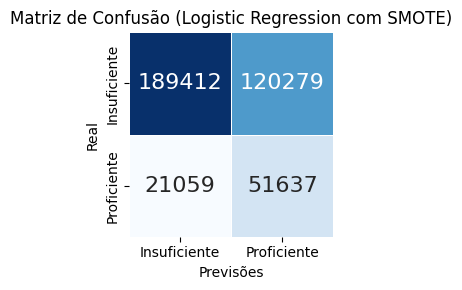


Coeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com SMOTE:
                                       Feature  Coefficient  Odds Ratio  \
0                                    Intercept     0.862524    2.369134   
16                    QTD_COMPUTADOR_3 ou mais     0.341465    1.407008   
25              IDADE_INTROD_ESC_Não respondeu     0.334939    1.397856   
20                     QTD_CARRO_Não respondeu     0.290320    1.336856   
11                 ESCOL_MAE_Superior completo     0.287923    1.333654   
15                       QTD_COMPUTADOR_1 ou 2     0.285748    1.330757   
26                    REPROVACAO_Não respondeu     0.273091    1.314020   
38                      POS_EF_Somente estudar     0.213423    1.237908   
18                            QTD_CARRO_1 ou 2     0.186715    1.205283   
8                     ESCOL_MAE_Médio completo     0.156850    1.169820   
22                                 GARAGEM_Sim     0.148066    1.159590   
3                 

In [7]:
# Como a regressão logística só trabalha com números, variáveis categóricas como 'Sexo' precisam virar colunas numéricas. O 'get_dummies()' faz isso. 
# O 'drop_first=True' remove uma categoria para evitar multicolinearidade, ou seja, se 'Masculino' = 1, então 'Feminino' = 0 automaticamente
X = pd.get_dummies(df_2019.drop(columns=['PROFICIENCIA_DESCRICAO']), drop_first=True)

# Redução do número de classes inicialmente adotado. Essa redução é necessária para a aplicação do modelo e contribui para um desempenho e estabilidade maiores
df_2019['PROFICIENCIA_DESCRICAO'] = (
    df_2019['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Como a regressão logística precisa prever números binários, então: 'Insuficiente' → 0 e 'Proficiente' → 1
y = df_2019['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Divisão dos dados em treino(ensinar o modelo) e teste(avaliar o modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Garantindo que os dados de entrada são do tipo float para evitar problemas matemáticos
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Exibindo a quantidade e porcentagem das classes antes do balanceamento
print("Distribuição das classes antes do balanceamento:")
print(y_train.value_counts())
print("\nPorcentagem das classes antes do balanceamento:")
print(y_train.value_counts(normalize=True) * 100)

# Aplicando SMOTE para balancear as classes no conjunto de treinamento
smote = SMOTE(random_state=42,k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# Exibindo a quantidade e porcentagem das classes após o balanceamento
print("\nDistribuição após SMOTE:")
print(y_train_smote.value_counts())
print("\nPercentual:")
print(y_train_smote.value_counts(normalize=True) * 100)

# Adicionando a constante (intercepto) para o modelo
X_train_smote = sm.add_constant(X_train_smote)
X_test = sm.add_constant(X_test)
X_test = X_test.reindex(columns=X_train_smote.columns, fill_value=0)

# Ajustando o modelo de regressão logística 
log_reg_stats = sm.Logit(y_train_smote, X_train_smote).fit()

# Previsões no conjunto de teste
y_pred = (log_reg_stats.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logistic Regression com SMOTE)")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = log_reg_stats.params
features = ['Intercept'] + list(X.columns)  # Inclui o intercepto no nome das variáveis

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = log_reg_stats.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})

# Ordenando por Odds Ratio
coef_df['Abs_Odds_Ratio'] = coef_df['Odds Ratio'].abs()
coef_df = coef_df.sort_values('Abs_Odds_Ratio', ascending=False)
print("\nCoeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com SMOTE:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio', 'p-value']])


#### 2021

In [8]:
# Como a regressão logística só trabalha com números, variáveis categóricas como 'Sexo' precisam virar colunas numéricas. O 'get_dummies()' faz isso. 
# O 'drop_first=True' remove uma categoria para evitar multicolinearidade, ou seja, se 'Masculino' = 1, então 'Feminino' = 0 automaticamente
X = pd.get_dummies(df_2021.drop(columns=['PROFICIENCIA_DESCRICAO']), drop_first=True)

# Redução do número de classes inicialmente adotado. Essa redução é necessária para a aplicação do modelo e contribui para um desempenho e estabilidade maiores
df_2021['PROFICIENCIA_DESCRICAO'] = (
    df_2021['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Como a regressão logística precisa prever números binários, então: 'Insuficiente' → 0 e 'Proficiente' → 1
y = df_2021['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Divisão dos dados em treino(ensinar o modelo) e teste(avaliar o modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Garantindo que os dados de entrada são do tipo float para evitar problemas matemáticos
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Exibindo a quantidade e porcentagem das classes antes do balanceamento
print("Distribuição das classes antes do balanceamento:")
print(y_train.value_counts())
print("\nPorcentagem das classes antes do balanceamento:")
print(y_train.value_counts(normalize=True) * 100)

# Aplicando SMOTE para balancear as classes no conjunto de treinamento
smote = SMOTE(random_state=42,k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# Exibindo a quantidade e porcentagem das classes após o balanceamento
print("\nDistribuição após SMOTE:")
print(y_train_smote.value_counts())
print("\nPercentual:")
print(y_train_smote.value_counts(normalize=True) * 100)

# Adicionando a constante (intercepto) para o modelo
X_train_smote = sm.add_constant(X_train_smote)
X_test = sm.add_constant(X_test)
X_test = X_test.reindex(columns=X_train_smote.columns, fill_value=0)

# Ajustando o modelo de regressão logística 
log_reg_stats = sm.Logit(y_train_smote, X_train_smote).fit()

# Previsões no conjunto de teste
y_pred = (log_reg_stats.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logistic Regression com SMOTE)")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = log_reg_stats.params
features = ['Intercept'] + list(X.columns)  # Inclui o intercepto no nome das variáveis

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = log_reg_stats.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})

# Ordenando por Odds Ratio
coef_df['Abs_Odds_Ratio'] = coef_df['Odds Ratio'].abs()
coef_df = coef_df.sort_values('Abs_Odds_Ratio', ascending=False)
print("\nCoeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com SMOTE:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio', 'p-value']])


Distribuição das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    1268427
1     240516
Name: count, dtype: int64

Porcentagem das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    84.060631
1    15.939369
Name: proportion, dtype: float64

Distribuição após SMOTE:
PROFICIENCIA_DESCRICAO
0    1268427
1    1268427
Name: count, dtype: int64

Percentual:
PROFICIENCIA_DESCRICAO
0    50.0
1    50.0
Name: proportion, dtype: float64
Optimization terminated successfully.
         Current function value: 0.585168
         Iterations 6


LinAlgError: Singular matrix

 #### 2023

Distribuição das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    1365681
1     276443
Name: count, dtype: int64

Porcentagem das classes antes do balanceamento:
PROFICIENCIA_DESCRICAO
0    83.165522
1    16.834478
Name: proportion, dtype: float64

Distribuição após SMOTE:
PROFICIENCIA_DESCRICAO
0    1365681
1    1365681
Name: count, dtype: int64

Percentual:
PROFICIENCIA_DESCRICAO
0    50.0
1    50.0
Name: proportion, dtype: float64
Optimization terminated successfully.
         Current function value: 0.598243
         Iterations 6

Acurácia: 0.6442

Classification Report:
              precision    recall  f1-score   support

Insuficiente       0.91      0.63      0.75    341565
 Proficiente       0.28      0.70      0.40     68967

    accuracy                           0.64    410532
   macro avg       0.59      0.66      0.57    410532
weighted avg       0.80      0.64      0.69    410532



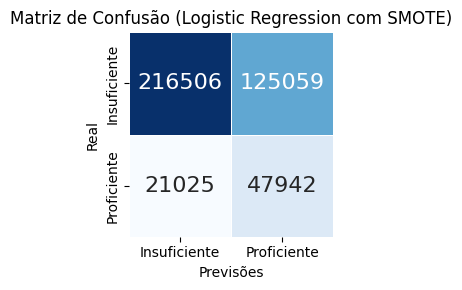


Coeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com SMOTE:
                                       Feature  Coefficient  Odds Ratio  \
4                           SEXO_Não respondeu     0.924191    2.519830   
2                               SEXO_Masculino     0.693715    2.001136   
0                                    Intercept     0.540220    1.716385   
19                    QTD_COMPUTADOR_3 ou mais     0.409118    1.505489   
24                       GARAGEM_Não respondeu     0.379740    1.461904   
14                 ESCOL_MAE_Superior completo     0.339779    1.404638   
18                       QTD_COMPUTADOR_1 ou 2     0.285693    1.330684   
33                  TEMPO_ESTUDO_Não respondeu     0.250661    1.284875   
11                    ESCOL_MAE_Médio completo     0.216240    1.241400   
41                      POS_EF_Somente estudar     0.161569    1.175354   
21                            QTD_CARRO_1 ou 2     0.157818    1.170953   
28              ID

In [9]:
# Como a regressão logística só trabalha com números, variáveis categóricas como 'Sexo' precisam virar colunas numéricas. O 'get_dummies()' faz isso. 
# O 'drop_first=True' remove uma categoria para evitar multicolinearidade, ou seja, se 'Masculino' = 1, então 'Feminino' = 0 automaticamente
X = pd.get_dummies(df_2023.drop(columns=['PROFICIENCIA_DESCRICAO']), drop_first=True)

# Redução do número de classes inicialmente adotado. Essa redução é necessária para a aplicação do modelo e contribui para um desempenho e estabilidade maiores
df_2023['PROFICIENCIA_DESCRICAO'] = (
    df_2023['PROFICIENCIA_DESCRICAO']
    .replace({
        'Básico': 'Insuficiente',
        'Avançado': 'Proficiente'
    })
)

# Como a regressão logística precisa prever números binários, então: 'Insuficiente' → 0 e 'Proficiente' → 1
y = df_2023['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Divisão dos dados em treino(ensinar o modelo) e teste(avaliar o modelo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Garantindo que os dados de entrada são do tipo float para evitar problemas matemáticos
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Exibindo a quantidade e porcentagem das classes antes do balanceamento
print("Distribuição das classes antes do balanceamento:")
print(y_train.value_counts())
print("\nPorcentagem das classes antes do balanceamento:")
print(y_train.value_counts(normalize=True) * 100)

# Aplicando SMOTE para balancear as classes no conjunto de treinamento
smote = SMOTE(random_state=42,k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# Exibindo a quantidade e porcentagem das classes após o balanceamento
print("\nDistribuição após SMOTE:")
print(y_train_smote.value_counts())
print("\nPercentual:")
print(y_train_smote.value_counts(normalize=True) * 100)

# Adicionando a constante (intercepto) para o modelo
X_train_smote = sm.add_constant(X_train_smote)
X_test = sm.add_constant(X_test)
X_test = X_test.reindex(columns=X_train_smote.columns, fill_value=0)

# Ajustando o modelo de regressão logística 
log_reg_stats = sm.Logit(y_train_smote, X_train_smote).fit()

# Previsões no conjunto de teste
y_pred = (log_reg_stats.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logistic Regression com SMOTE)")
plt.tight_layout()
plt.show()

# Coeficientes do modelo
coef = log_reg_stats.params
features = ['Intercept'] + list(X.columns)  # Inclui o intercepto no nome das variáveis

# Calculando as Odds Ratios
odds_ratios = np.exp(coef)

# Calculando os p-values
p_values = log_reg_stats.pvalues

# Criando o DataFrame para exibir os coeficientes, Odds Ratios e p-values
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coef.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
})

# Ordenando por Odds Ratio
coef_df['Abs_Odds_Ratio'] = coef_df['Odds Ratio'].abs()
coef_df = coef_df.sort_values('Abs_Odds_Ratio', ascending=False)
print("\nCoeficientes, Odds Ratios e p-values do Modelo de Regressão Logística com SMOTE:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio', 'p-value']])
